# Аналіз датасету Food-101 (EDA)
У цьому зошиті ми проведемо розвідувальний аналіз даних (Exploratory Data Analysis) для датасету **Food-101**.
Ми перевіримо:
1. Баланс класів у тренувальній та тестовій вибірках.
2. Розподіл розмірів зображень (ширина, висота, співвідношення сторін).
3. Приклади зображень.

Згенеровані графіки також будуть збережені у папку `../data/eda_results/` для використання у звітах.


In [1]:
import os
import json
import random
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# Створюємо папку для результатів
results_dir = Path("../data/eda_results")
results_dir.mkdir(parents=True, exist_ok=True)

data_dir = Path("../data/food-101")
meta_dir = data_dir / "meta"
images_dir = data_dir / "images"

print(f"Data directory exists: {data_dir.exists()}")


Data directory exists: True


## 1. Аналіз балансу класів
Завантажимо списки тренувальних та тестових зображень.


In [2]:
def load_meta_file(filepath):
    with open(filepath, 'r') as f:
        # Food-101 metadata files contain lines like 'class_name/image_name'
        lines = [line.strip() for line in f.readlines()]
    return lines

train_images = load_meta_file(meta_dir / "train.txt")
test_images = load_meta_file(meta_dir / "test.txt")

print(f"Total training images: {len(train_images)}")
print(f"Total test images: {len(test_images)}")

# Рахуємо зображення по класах
def get_class_counts(image_paths):
    counts = {}
    for path in image_paths:
        cls = path.split('/')[0]
        counts[cls] = counts.get(cls, 0) + 1
    return counts

train_counts = get_class_counts(train_images)
test_counts = get_class_counts(test_images)

df_counts = pd.DataFrame({
    'Train': pd.Series(train_counts),
    'Test': pd.Series(test_counts)
})

display(df_counts.head(10))
display(df_counts.describe())


Total training images: 75750
Total test images: 25250


,Train,Test
apple_pie,750,250
baby_back_ribs,750,250
baklava,750,250
beef_carpaccio,750,250
beef_tartare,750,250
beet_salad,750,250
beignets,750,250
bibimbap,750,250
bread_pudding,750,250
breakfast_burrito,750,250


,Train,Test
count,101.0,101.0
mean,750.0,250.0
std,0.0,0.0
min,750.0,250.0
25%,750.0,250.0
50%,750.0,250.0
75%,750.0,250.0
max,750.0,250.0


Як ми бачимо, датасет ідеально збалансований: кожен з 101 класів має рівно 750 тренувальних та 250 тестових зображень.

## 2. Аналіз розмірів зображень
Оскільки зчитування 100,000 зображень може зайняти багато часу, ми візьмемо випадкову вибірку з 5,000 зображень.


Reading image sizes:   0%|          | 0/5000 [00:00<?, ?it/s]

Reading image sizes:   4%|▎         | 185/5000 [00:00<00:02, 1845.15it/s]

Reading image sizes:   9%|▊         | 433/5000 [00:00<00:02, 2216.69it/s]

Reading image sizes:  14%|█▍        | 712/5000 [00:00<00:01, 2477.31it/s]

Reading image sizes:  20%|█▉        | 999/5000 [00:00<00:01, 2631.36it/s]

...

Reading image sizes:  72%|███████▏  | 3576/5000 [00:01<00:00, 3259.57it/s]

Reading image sizes:  78%|███████▊  | 3924/5000 [00:01<00:00, 3323.31it/s]

Reading image sizes:  86%|████████▌ | 4296/5000 [00:01<00:00, 3441.96it/s]

Reading image sizes:  93%|█████████▎| 4662/5000 [00:01<00:00, 3505.63it/s]

Reading image sizes: 100%|██████████| 5000/5000 [00:01<00:00, 3130.77it/s]

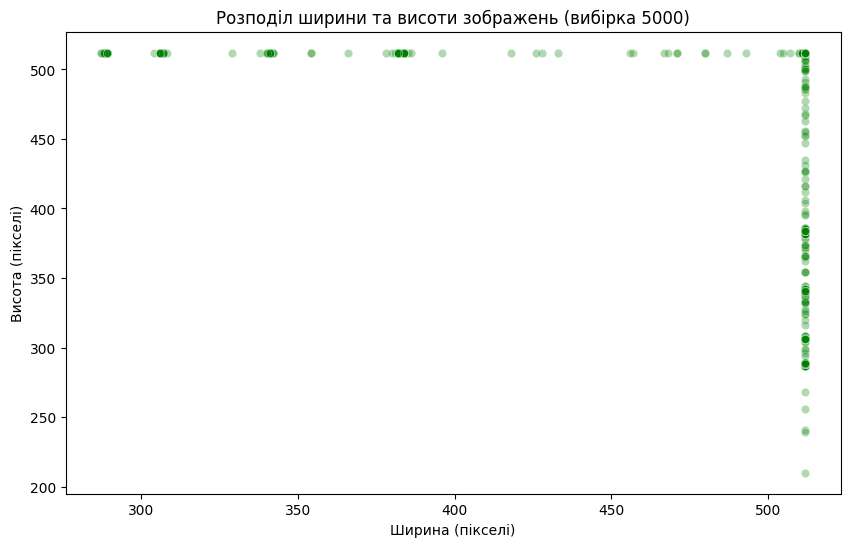

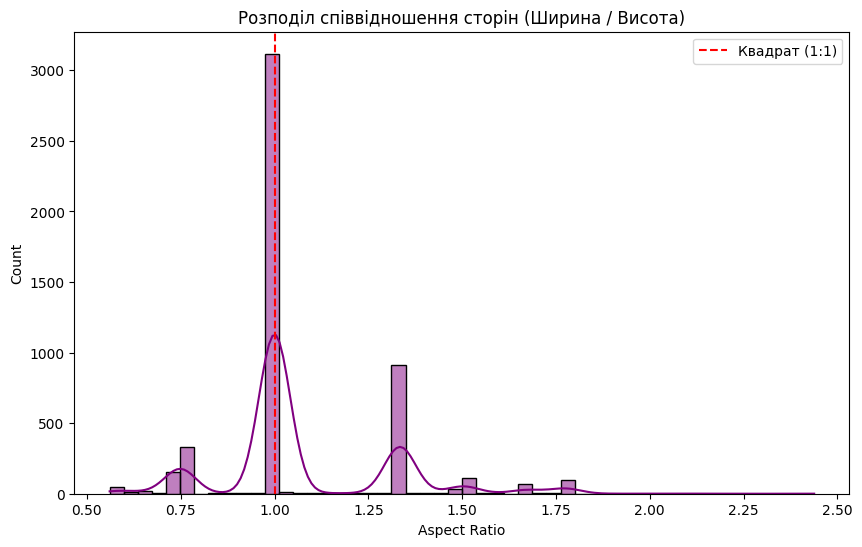

,Width,Height,Aspect Ratio
count,5000.000000,5000.000000,5000.000000
mean,496.087400,474.646800,1.074272
std,44.995941,65.695833,0.228427
min,287.000000,210.000000,0.560547
25%,512.000000,385.000000,1.000000
50%,512.000000,512.000000,1.000000
75%,512.000000,512.000000,1.329870
max,512.000000,512.000000,2.438095


In [3]:
sample_size = 5000
all_images = train_images + test_images
sample_images = random.sample(all_images, sample_size)

widths = []
heights = []
aspect_ratios = []

for img_path in tqdm(sample_images, desc="Reading image sizes"):
    full_path = images_dir / f"{img_path}.jpg"
    if full_path.exists():
        with Image.open(full_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)

df_sizes = pd.DataFrame({
    'Width': widths,
    'Height': heights,
    'Aspect Ratio': aspect_ratios
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Width', y='Height', data=df_sizes, alpha=0.3, color='green')
plt.title('Розподіл ширини та висоти зображень (вибірка 5000)')
plt.xlabel('Ширина (пікселі)')
plt.ylabel('Висота (пікселі)')
plt.savefig(results_dir / 'image_sizes_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Гістограма співвідношення сторін
plt.figure(figsize=(10, 6))
sns.histplot(df_sizes['Aspect Ratio'], bins=50, kde=True, color='purple')
plt.title('Розподіл співвідношення сторін (Ширина / Висота)')
plt.axvline(1.0, color='red', linestyle='--', label='Квадрат (1:1)')
plt.legend()
plt.savefig(results_dir / 'aspect_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

display(df_sizes.describe())


## 3. Приклади зображень
Давайте виведемо кілька випадкових зображень, щоб оцінити їх якість та різноманітність.


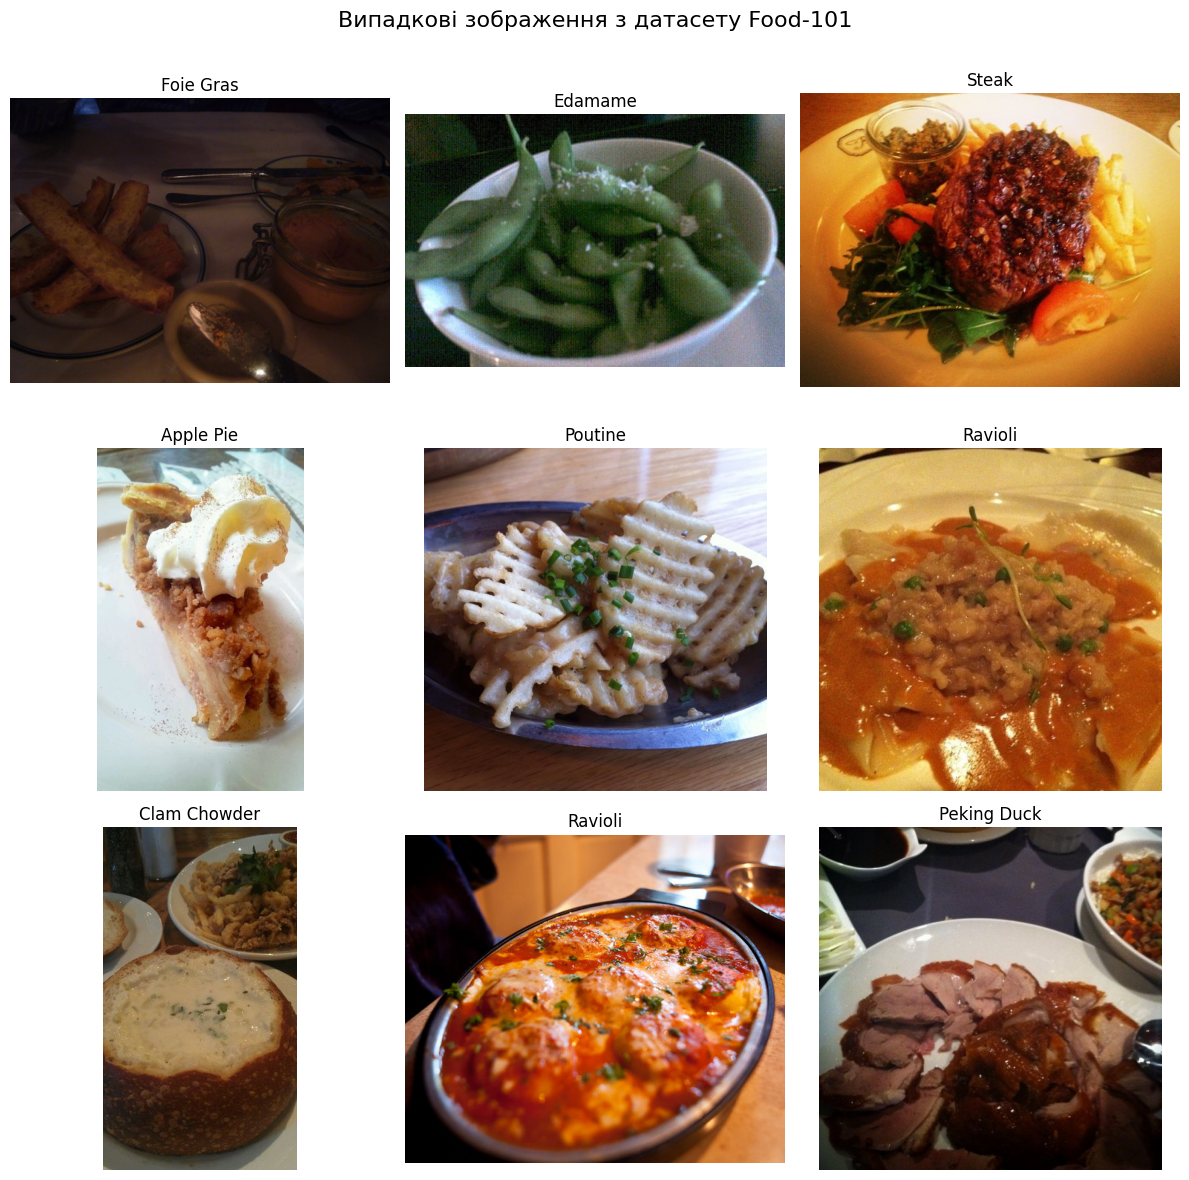

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Випадкові зображення з датасету Food-101', fontsize=16)

random_samples = random.sample(all_images, 9)

for idx, ax in enumerate(axes.flatten()):
    img_path = random_samples[idx]
    cls_name = img_path.split('/')[0]
    full_path = images_dir / f"{img_path}.jpg"
    
    if full_path.exists():
        img = Image.open(full_path)
        ax.imshow(img)
        ax.set_title(cls_name.replace('_', ' ').title())
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig(results_dir / 'sample_grid.png', dpi=300, bbox_inches='tight')
plt.show()
